# Program 9 - VGG16 — From Scratch & Transfer Learning

## Cell 1 — Install & Import Dependencies

In [1]:
# Install required packages (run once)
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install matplotlib numpy pillow tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import CIFAR10, ImageFolder

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from tqdm import tqdm
import os, time, copy

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')
print(f'Torchvision version: {torchvision.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


## Cell 2 — VGG16 Architecture From Scratch

In [2]:
class VGG16(nn.Module):
    """
    VGG-16 architecture as described in the original paper.
    Input: (batch, 3, 224, 224)
    """
    def __init__(self, num_classes=1000, dropout=0.5):
        super(VGG16, self).__init__()

        # ── Feature extractor (5 blocks) ──────────────────────────────────
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),   nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),         # 112×112

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 56×56

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 28×28

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 14×14

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 7×7
        )

        # ── Adaptive pool (makes model input-size agnostic) ───────────────
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))

        # ── Classifier (3 fully-connected layers) ─────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096), nn.ReLU(inplace=True), nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),         nn.ReLU(inplace=True), nn.Dropout(p=dropout),
            nn.Linear(4096, num_classes),
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)


# Quick sanity check
model_scratch = VGG16(num_classes=10).to(device)
dummy = torch.randn(2, 3, 224, 224).to(device)
out   = model_scratch(dummy)
print('VGG16 (scratch) output shape:', out.shape)   # (2, 10)

# Parameter count
total_params = sum(p.numel() for p in model_scratch.parameters())
print(f'Total parameters: {total_params:,}  (~{total_params/1e6:.1f}M)')

VGG16 (scratch) output shape: torch.Size([2, 10])
Total parameters: 134,301,514  (~134.3M)


## Cell 3 — Model Summary / Layer Inspection

In [3]:
def model_summary(model, input_size=(3, 224, 224)):
    """Print layer-by-layer summary with output shapes."""
    print(f"{'Layer':<40} {'Output Shape':<25} {'Params':>12}")
    print('─' * 80)

    hooks = []
    shapes = {}

    def hook_fn(name):
        def fn(module, inp, out):
            shapes[name] = tuple(out.shape[1:])
        return fn

    for name, layer in model.named_modules():
        if len(list(layer.children())) == 0:  # leaf modules only
            hooks.append(layer.register_forward_hook(hook_fn(name)))

    x = torch.randn(1, *input_size).to(device)
    model.eval()
    with torch.no_grad():
        model(x)

    for name, layer in model.named_modules():
        if len(list(layer.children())) == 0:
            params = sum(p.numel() for p in layer.parameters())
            shape  = shapes.get(name, '-')
            print(f'{name:<40} {str(shape):<25} {params:>12,}')

    for h in hooks:
        h.remove()

model_summary(model_scratch)

Layer                                    Output Shape                    Params
────────────────────────────────────────────────────────────────────────────────
features.0                               (64, 224, 224)                   1,792
features.1                               (64, 224, 224)                       0
features.2                               (64, 224, 224)                  36,928
features.3                               (64, 224, 224)                       0
features.4                               (64, 112, 112)                       0
features.5                               (128, 112, 112)                 73,856
features.6                               (128, 112, 112)                      0
features.7                               (128, 112, 112)                147,584
features.8                               (128, 112, 112)                      0
features.9                               (128, 56, 56)                        0
features.10                            

## Cell 4 — Pretrained VGG16 (Transfer Learning)

In [4]:
NUM_CLASSES = 10   # Change for your dataset

# Load ImageNet-pretrained VGG16
model_pretrained = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# ── Strategy 1: Fine-tune only the classifier ─────────────────────────────
for param in model_pretrained.features.parameters():
    param.requires_grad = False          # Freeze convolutional layers

# Replace final FC layer
in_features = model_pretrained.classifier[6].in_features
model_pretrained.classifier[6] = nn.Linear(in_features, NUM_CLASSES)

model_pretrained = model_pretrained.to(device)

# Only classifier parameters will be optimised
trainable = sum(p.numel() for p in model_pretrained.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_pretrained.parameters())
print(f'Trainable parameters : {trainable:,}')
print(f'Frozen   parameters  : {total - trainable:,}')
print(f'Total    parameters  : {total:,}')

# Quick forward pass
x   = torch.randn(2, 3, 224, 224).to(device)
out = model_pretrained(x)
print('Pretrained VGG16 output shape:', out.shape)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 226MB/s]  


Trainable parameters : 119,586,826
Frozen   parameters  : 14,714,688
Total    parameters  : 134,301,514
Pretrained VGG16 output shape: torch.Size([2, 10])


## Cell 5 — Data Transforms & CIFAR-10 Loader

100%|██████████| 170M/170M [00:06<00:00, 25.9MB/s] 


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 40,000  |  Val: 10,000  |  Test: 10,000


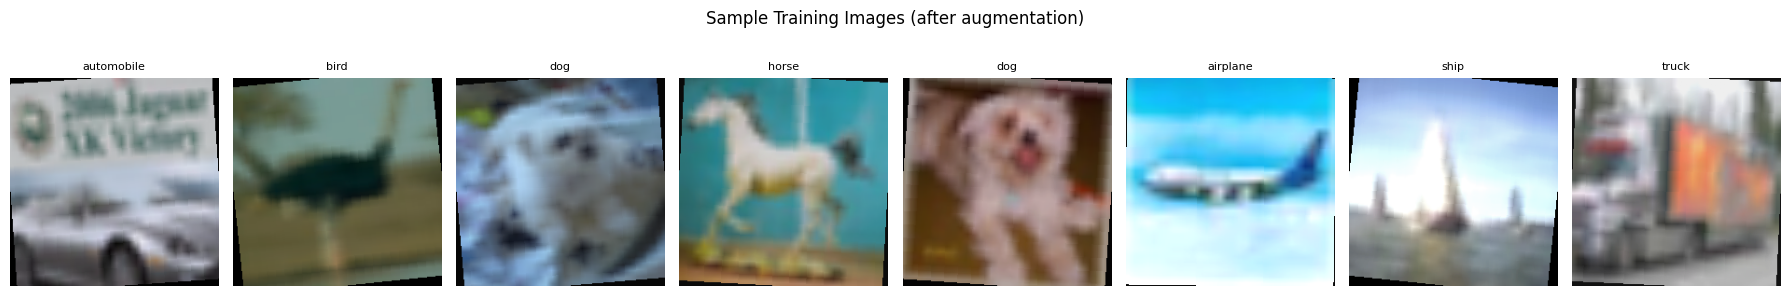

In [5]:
# ── Transforms ───────────────────────────────────────────────────────────
# VGG16 expects 224×224; CIFAR-10 is 32×32 — we upscale.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                         std =[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ── Datasets ─────────────────────────────────────────────────────────────
DATA_ROOT  = './data'
BATCH_SIZE = 32

train_dataset = CIFAR10(root=DATA_ROOT, train=True,  download=True, transform=train_transform)
test_dataset  = CIFAR10(root=DATA_ROOT, train=False, download=True, transform=val_transform)

# 80/20 train-validation split from the training set
n_val   = int(0.2 * len(train_dataset))
n_train = len(train_dataset) - n_val
train_ds, val_ds = random_split(train_dataset, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASSES = train_dataset.classes
print('Classes:', CLASSES)
print(f'Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_dataset):,}')

# ── Visualise a batch ────────────────────────────────────────────────────
images, labels = next(iter(train_loader))
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
imgs_denorm = (images[:8] * std + mean).clamp(0, 1)

fig, axes = plt.subplots(1, 8, figsize=(18, 3))
for ax, img, lbl in zip(axes, imgs_denorm, labels[:8]):
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(CLASSES[lbl], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Training Images (after augmentation)', y=1.02)
plt.tight_layout()
plt.show()

## Cell 6 — Training Loop

In [6]:
def train_model(model, train_loader, val_loader, num_epochs=10,
                lr=1e-4, weight_decay=5e-4):
    criterion  = nn.CrossEntropyLoss()
    optimizer  = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=weight_decay)
    scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(1, num_epochs + 1):
        start = time.time()

        # ── Training ──────────────────────────────────────────────────────
        model.train()
        running_loss = correct = total = 0
        for imgs, lbls in tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs} [Train]', leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct  += preds.eq(lbls).sum().item()
            total    += imgs.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total * 100

        # ── Validation ────────────────────────────────────────────────────
        model.eval()
        running_loss = correct = total = 0
        with torch.no_grad():
            for imgs, lbls in tqdm(val_loader, desc=f'Epoch {epoch}/{num_epochs} [Val]  ', leave=False):
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs    = model(imgs)
                loss       = criterion(outputs, lbls)
                running_loss += loss.item() * imgs.size(0)
                _, preds = outputs.max(1)
                correct  += preds.eq(lbls).sum().item()
                total    += imgs.size(0)

        val_loss = running_loss / total
        val_acc  = correct / total * 100

        scheduler.step()
        elapsed = time.time() - start

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch [{epoch:02d}/{num_epochs}]  '
              f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  '
              f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%  '
              f'({elapsed:.1f}s)')

    print(f'\nBest Validation Accuracy: {best_val_acc:.2f}%')
    model.load_state_dict(best_weights)
    return model, history


# ── Run training (set num_epochs to 1 for a quick smoke-test) ─────────────
NUM_EPOCHS = 1   # Increase for real training
trained_model, history = train_model(model_pretrained, train_loader, val_loader,
                                     num_epochs=NUM_EPOCHS, lr=1e-4)

Epoch [01/1]  Train Loss: 0.7823  Train Acc: 72.46%  Val Loss: 0.5882  Val Acc: 79.64%  (335.5s)

Best Validation Accuracy: 79.64%


## Cell 7 — Plot Training Curves

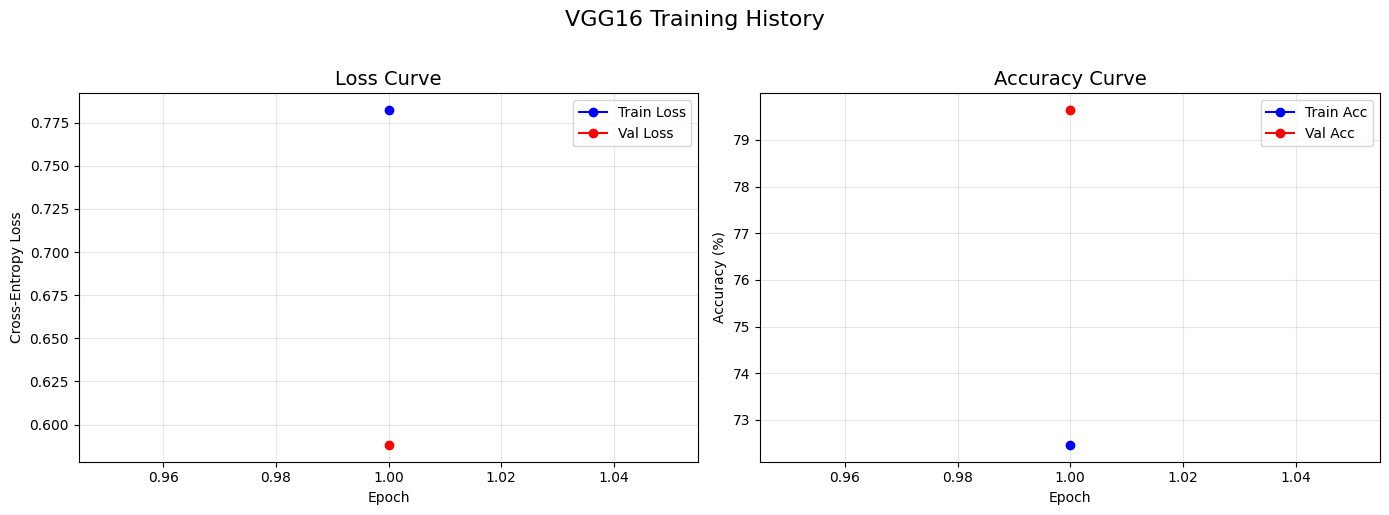

Saved training_curves.png


In [7]:
epochs = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs, history['val_loss'],   'r-o', label='Val Loss')
ax1.set_title('Loss Curve',     fontsize=14)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
ax2.plot(epochs, history['val_acc'],   'r-o', label='Val Acc')
ax2.set_title('Accuracy Curve', fontsize=14)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('VGG16 Training History', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')

## Cell 8 — Evaluate on Test Set + Confusion Matrix

Testing: 100%|██████████| 313/313 [01:00<00:00,  5.18it/s]


Test Accuracy: 85.16%

              precision    recall  f1-score   support

    airplane       0.87      0.85      0.86      1000
  automobile       0.91      0.92      0.91      1000
        bird       0.81      0.84      0.82      1000
         cat       0.80      0.65      0.72      1000
        deer       0.78      0.87      0.82      1000
         dog       0.79      0.83      0.81      1000
        frog       0.92      0.83      0.88      1000
       horse       0.89      0.85      0.87      1000
        ship       0.88      0.92      0.90      1000
       truck       0.86      0.95      0.90      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



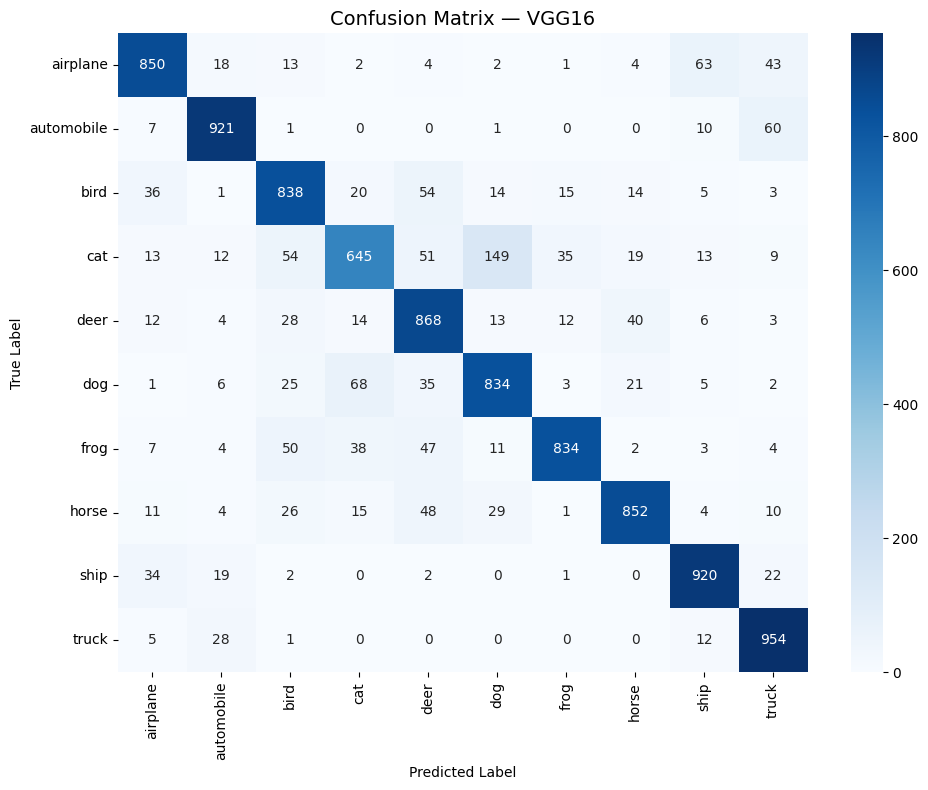

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

trained_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc='Testing'):
        imgs = imgs.to(device)
        out  = trained_model(imgs)
        _, preds = out.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.numpy())

test_acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100
print(f'Test Accuracy: {test_acc:.2f}%\n')
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# Confusion matrix
cm_arr = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — VGG16', fontsize=14)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Single-Image Inference

Top-5 predictions:
  dog              73.21%
  cat              15.41%
  horse            9.67%
  deer             0.53%
  bird             0.51%


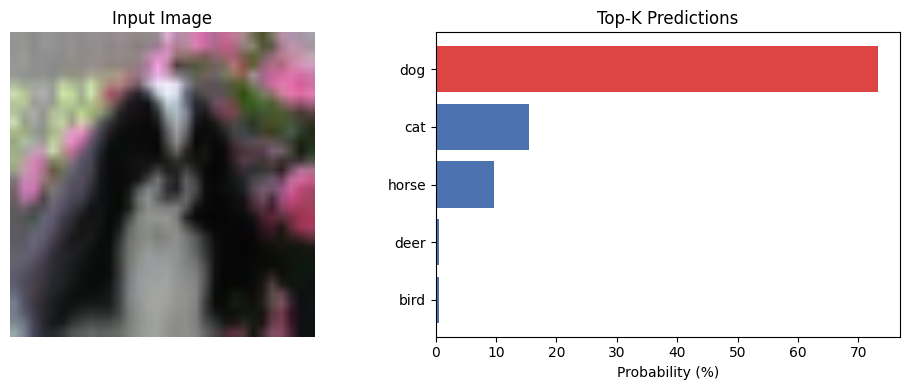


Ground Truth : dog
Prediction   : dog (73.2%)


In [9]:
def predict_image(model, img_path_or_tensor, top_k=5):
    """
    Run inference on a single image.
    Accepts a file path (str) or a PIL Image or a tensor.
    """
    infer_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])

    if isinstance(img_path_or_tensor, str):
        img = Image.open(img_path_or_tensor).convert('RGB')
    elif isinstance(img_path_or_tensor, Image.Image):
        img = img_path_or_tensor.convert('RGB')
    else:
        raise TypeError('Expected str path or PIL.Image')

    tensor = infer_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1)

    topk_probs, topk_idxs = probs.topk(top_k, dim=1)
    topk_probs = topk_probs.squeeze().cpu().numpy()
    topk_idxs  = topk_idxs.squeeze().cpu().numpy()

    print(f'Top-{top_k} predictions:')
    for p, idx in zip(topk_probs, topk_idxs):
        print(f'  {CLASSES[idx]:<15}  {p*100:.2f}%')

    # Visualise
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img.resize((224, 224)))
    ax1.set_title('Input Image'); ax1.axis('off')

    colors = ['#4C72B0' if i > 0 else '#DD4444' for i in range(top_k-1, -1, -1)]
    ax2.barh([CLASSES[i] for i in reversed(topk_idxs)],
             [p*100 for p in reversed(topk_probs)], color=colors)
    ax2.set_xlabel('Probability (%)'); ax2.set_title('Top-K Predictions')
    plt.tight_layout()
    plt.show()
    return CLASSES[topk_idxs[0]], topk_probs[0]


# Example: pick a random test image
idx = 42
sample_img_tensor, sample_label = test_dataset[idx]
# Convert tensor back to PIL for our function
mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
pil_img = transforms.ToPILImage()((sample_img_tensor * std_t + mean_t).clamp(0,1))

pred_class, pred_prob = predict_image(trained_model, pil_img)
print(f'\nGround Truth : {CLASSES[sample_label]}')
print(f'Prediction   : {pred_class} ({pred_prob*100:.1f}%)')

## Cell 10 — Feature Map Visualization

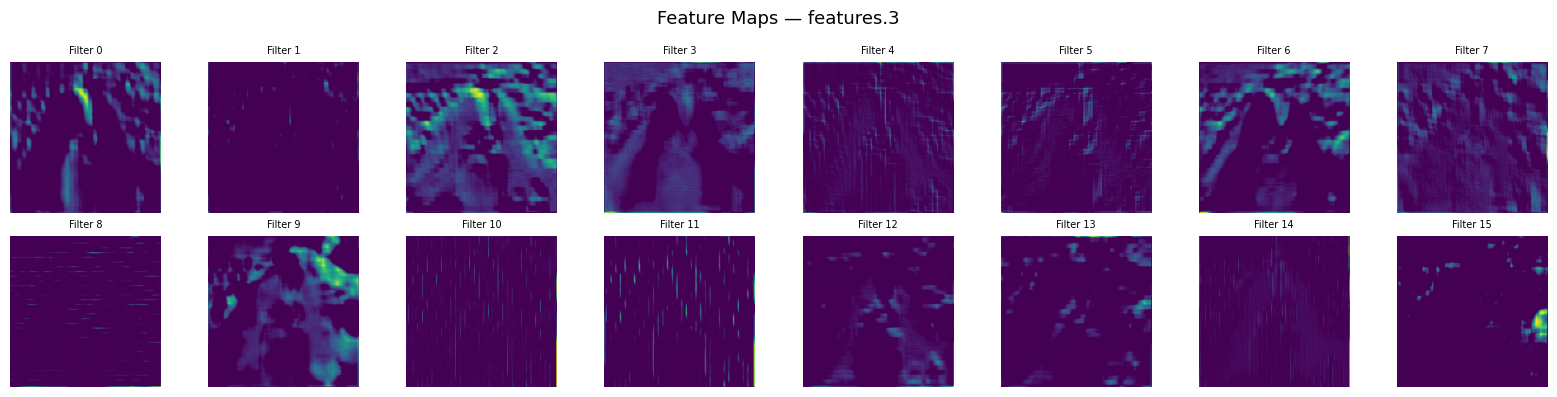

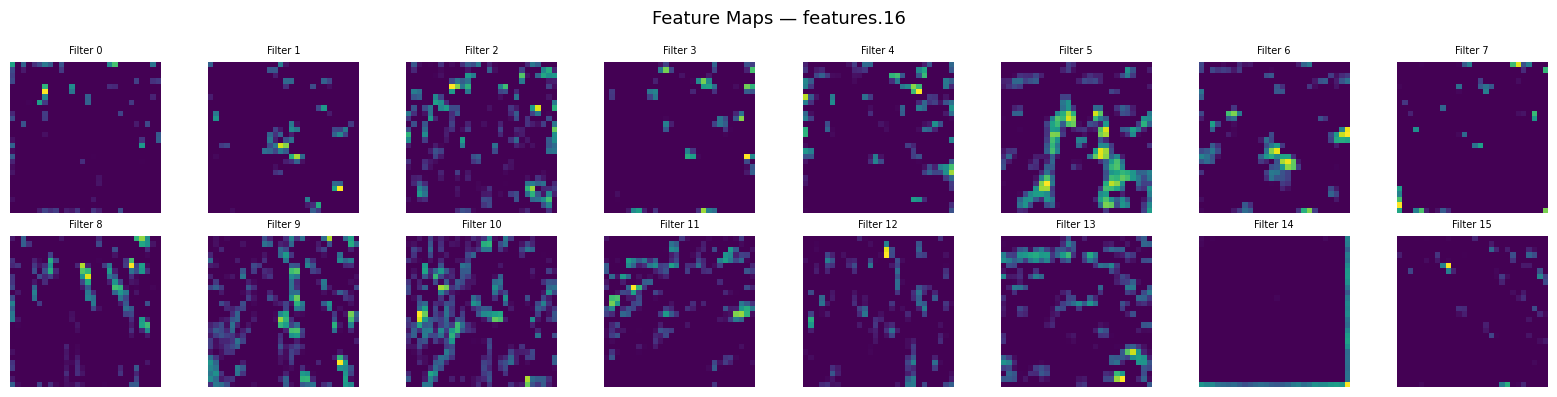

In [10]:
def visualize_feature_maps(model, img_tensor, layer_name='features.3', n_filters=16):
    """
    Extract and display feature maps at a given layer.
    img_tensor: (1, C, H, W) already normalised.
    """
    activation = {}

    def get_activation(name):
        def hook(module, inp, out):
            activation[name] = out.detach()
        return hook

    # Register hook on target layer
    for name, module in model.named_modules():
        if name == layer_name:
            handle = module.register_forward_hook(get_activation(layer_name))
            break

    model.eval()
    with torch.no_grad():
        model(img_tensor.to(device))
    handle.remove()

    maps = activation[layer_name][0].cpu()  # (C, H, W)
    n    = min(n_filters, maps.shape[0])
    cols = 8
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    axes = axes.flatten()
    for i in range(n):
        axes[i].imshow(maps[i].numpy(), cmap='viridis')
        axes[i].set_title(f'Filter {i}', fontsize=7)
        axes[i].axis('off')
    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Feature Maps — {layer_name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'feature_maps_{layer_name.replace(".","_")}.png', dpi=120)
    plt.show()


# Visualise Block-1 ReLU (features.3) and Block-3 ReLU (features.16)
sample_input = sample_img_tensor.unsqueeze(0)  # (1,3,224,224)
visualize_feature_maps(trained_model, sample_input, layer_name='features.3',  n_filters=16)
visualize_feature_maps(trained_model, sample_input, layer_name='features.16', n_filters=16)

In [12]:
import torch.nn as nn

# Disable inplace ReLU for VGG
for m in trained_model.modules():
    if isinstance(m, nn.ReLU):
        m.inplace = False

trained_model.eval()

if sample_input.ndim == 3:
    sample_input = sample_input.unsqueeze(0)

sample_input = sample_input.to(device)

target_layer = trained_model.features[28]

gradcam = GradCAM(
    trained_model,
    target_layer
)

cam_map, pred_idx = gradcam.generate(sample_input)

## Cell 11 — Grad-CAM Explainability

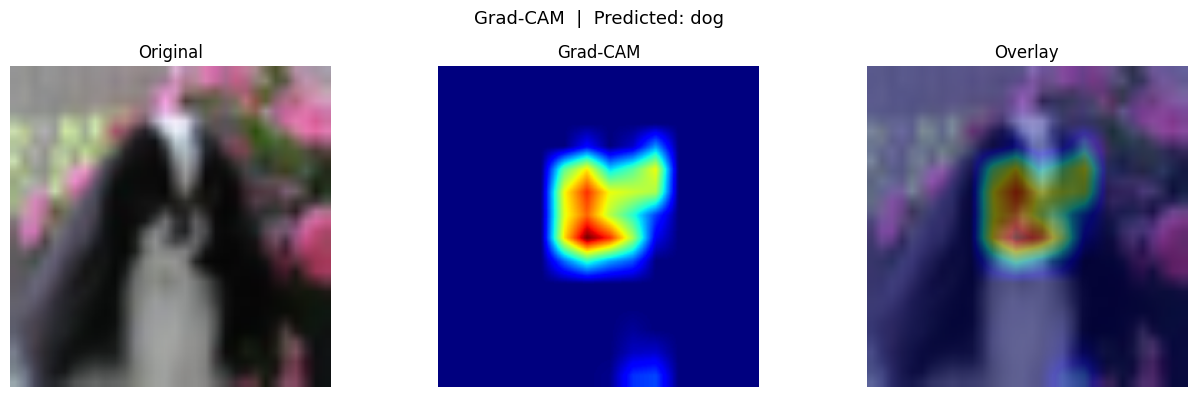

Saved gradcam.png


In [13]:
class GradCAM:
    """
    Gradient-weighted Class Activation Mapping (Selvaraju et al., 2017).
    Highlights image regions most influential for the predicted class.
    """
    def __init__(self, model, target_layer):
        self.model   = model
        self.gradients  = None
        self.activations = None

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, img_tensor, class_idx=None):
        self.model.eval()
        img_tensor = img_tensor.to(device).requires_grad_(True)
        logits = self.model(img_tensor)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        self.model.zero_grad()
        logits[0, class_idx].backward()

        # Global average pool gradients over spatial dims
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)   # (1, C, 1, 1)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def overlay_gradcam(original_pil, cam):
    img_np  = np.array(original_pil.resize((224, 224))).astype(np.float32) / 255
    heatmap = cm.jet(cam)[:, :, :3]
    overlay = 0.6 * img_np + 0.4 * heatmap
    return np.clip(overlay, 0, 1)


# Use last conv layer (features.28) for richest spatial info
target_layer = trained_model.features[28]
gradcam = GradCAM(trained_model, target_layer)

cam_map, pred_idx = gradcam.generate(sample_input)
overlay = overlay_gradcam(pil_img, cam_map)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(pil_img.resize((224,224)));  axes[0].set_title('Original');   axes[0].axis('off')
axes[1].imshow(cam_map, cmap='jet');         axes[1].set_title('Grad-CAM');   axes[1].axis('off')
axes[2].imshow(overlay);                     axes[2].set_title('Overlay');    axes[2].axis('off')
plt.suptitle(f'Grad-CAM  |  Predicted: {CLASSES[pred_idx]}', fontsize=13)
plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved gradcam.png')

## Cell 12 — Save & Load Checkpoint

In [14]:
CKPT_PATH = 'vgg16_cifar10_best.pth'

# ── Save ──────────────────────────────────────────────────────────────────
torch.save({
    'epoch'       : NUM_EPOCHS,
    'model_state' : trained_model.state_dict(),
    'val_acc'     : max(history['val_acc']),
    'classes'     : CLASSES,
    'num_classes' : NUM_CLASSES,
}, CKPT_PATH)
print(f'Checkpoint saved → {CKPT_PATH}')

# ── Load ──────────────────────────────────────────────────────────────────
def load_vgg16_checkpoint(ckpt_path, device='cpu'):
    ckpt      = torch.load(ckpt_path, map_location=device)
    num_cls   = ckpt['num_classes']
    model     = models.vgg16(weights=None)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_cls)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    print(f"Loaded checkpoint (epoch {ckpt['epoch']}, val_acc={ckpt['val_acc']:.2f}%)")
    return model, ckpt['classes']

loaded_model, loaded_classes = load_vgg16_checkpoint(CKPT_PATH, device=device)
loaded_model = loaded_model.to(device)
print('Classes:', loaded_classes)

Checkpoint saved → vgg16_cifar10_best.pth
Loaded checkpoint (epoch 1, val_acc=79.64%)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
